# 5. Demo Pipeline

A complete pipeline in one notebook: **download** raw volumes straight from a
public archive, **archive** them, **plot** them, and cut a **vertical
cross-section**.

| radar | site | format | reader |
|---|---|---|---|
| `FANJ` | Anjalankoski, southern Finland | ODIM HDF5 | `open_odim_datatree` |
| `FVIH` | Vihti, near Helsinki | ODIM HDF5 | `open_odim_datatree` |

FMI publishes every volume openly and needs no credentials. The case below is
only the default — section 1 is where you pick a different time.

The two radars are ~150 km apart and both see the same weather, so the same
storm is archived twice, from two different points of view.

In [ ]:
import urllib.parse
import urllib.request
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import xradar

import raddb
from raddb.lut import suggest_crs

print("raddb", raddb.__version__, "| xradar", xradar.__version__)

raddb 0.1.dev5+gde6070734.d20260323 | xradar 0.11.1


## Configuration

`RAW_DIR` is where the downloaded files land, `ARCHIVE_DIR` is the archive the
other tutorials use — the radars below are simply added to it.

In [ ]:
# --------------------------------------------------------------------------
# CONFIGURATION — edit these two paths to point at your own machine
# --------------------------------------------------------------------------
RAW_DIR = Path("~/Desktop/LTE_project/ltenas8/data/RADAR/tutorial_raw").expanduser()
ARCHIVE_DIR = Path("~/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive").expanduser()

RAW_DIR.mkdir(parents=True, exist_ok=True)

# FMI names its radars with 5-character ODIM NOD codes and a RadDB name is at
# most 4, so each is aliased: "fianj" -> "FANJ", "fivih" -> "FVIH".
SOURCES = {"FANJ": "fianj", "FVIH": "fivih"}

print("raw files:", RAW_DIR)
print("archive  :", ARCHIVE_DIR)

raw files: /home/erik_poschivo/Desktop/LTE_project/ltenas8/data/RADAR/tutorial_raw
archive  : /home/erik_poschivo/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive


## 1. Which volume?

**This is the cell to edit to run the demo on other weather.** One timestamp per
radar, UTC. Each is resolved to the volume **at or before** the time asked for.

FMI publishes one file every **5 minutes**, but the scan strategy cycles over
15 minutes: only `:00`, `:15`, `:30` and `:45` are the full 13-sweep volume,
while `:05`/`:10` and their repeats are two shorter task sets. RadDB stores one
geometry per radar, so the timestamp is rounded down to the **quarter hour** —
mixing the three task sets would be refused as a scan-strategy change.

The default is a summer thunderstorm on **10 August 2024**, the strongest echo
in this corpus: 59 dBZ at Anjalankoski, and over 17,000 gates above 35 dBZ.

In [ ]:
# --------------------------------------------------------------------------
# WHICH TIMESTEP? — one UTC timestamp per radar, edit freely
# --------------------------------------------------------------------------
TIMES = {
    "FANJ": "2024-08-10 12:00",
    "FVIH": "2024-08-10 12:00",
}

for name, when in TIMES.items():
    print(f"{name:<5} {pd.Timestamp(when).floor('15min'):%Y-%m-%d %H:%M} UTC")

FANJ  2024-08-10 12:00 UTC
FVIH  2024-08-10 12:00 UTC


## 2. Download

In [ ]:
BUCKET = "https://fmi-opendata-radar-volume-hdf5.s3.eu-west-1.amazonaws.com"


def download(nod, when, dest_dir):
    """Fetch one FMI ODIM volume into *dest_dir* and return its path."""
    t = pd.Timestamp(when).floor("15min")  # only the quarter hour is the 13-sweep scan
    url = f"{BUCKET}/{t:%Y/%m/%d}/{nod}/{t:%Y%m%d%H%M}_{nod}_PVOL.h5"
    out = dest_dir / Path(urllib.parse.urlparse(url).path).name
    if not out.exists():
        urllib.request.urlretrieve(url, out)
    return out


paths = {}
for name, nod in SOURCES.items():
    paths[name] = download(nod, TIMES[name], RAW_DIR)
    print(f"{name:<5} {paths[name].name:<32} {paths[name].stat().st_size / 1e6:6.1f} MB")

FANJ  202408101200_fianj_PVOL.h5         30.9 MB
FVIH  202408101200_fivih_PVOL.h5         30.9 MB


## 3. Archive

Each file is opened with xradar's ODIM reader and handed to `archive()` — no
preparation in between. A real volume often drops a ray or two (358 of 360
here); RadDB reads that as a rotation with holes, keeps the missing rays' slots
in the LUT so a later volume that records them still joins, and archives what is
there.

The CRS is **mandatory to write**. `suggest_crs()` returns the UTM zone of each
site, but both radars are in Finland, so they are archived in the national grid
**EPSG:3067** — the same frame tutorial 1 used, which is what lets the two share
one AOI frame.

`FANJ` is already in the archive from tutorial 1. A radar's LUT is generated once
and then reused, so this volume joins the geometry that is already there;
`FVIH` is new, and its LUT is built here.

In [ ]:
for name, path in paths.items():
    dt = xradar.io.open_odim_datatree(str(path))
    site = dt["/"].ds
    lat, lon = float(site["latitude"]), float(site["longitude"])
    n_sweeps = sum(1 for g in dt.groups if g.startswith("/sweep_"))
    print(
        f"{name}: {n_sweeps} sweeps, site {lat:.2f}, {lon:.2f} "
        f"-> suggest_crs EPSG:{suggest_crs(latitude=lat, longitude=lon)}, archived in EPSG:3067",
    )

    raddb.RadDB(archive_dir=ARCHIVE_DIR, crs=3067).archive(datatree=dt, radar=name)

FANJ: 13 sweeps, site 60.90, 27.11 -> suggest_crs EPSG:32635, archived in EPSG:3067


RadDB archive
  archive_dir : /home/erik_poschivo/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive
  crs         : 3067
  radars      : ['FANJ']
  filter      : keep DBZH > 0.0
  volumes     : 1 archived, 0 failed
  elapsed     : 3s


FVIH: 13 sweeps, site 60.56, 24.50 -> suggest_crs EPSG:32635, archived in EPSG:3067


RadDB archive
  archive_dir : /home/erik_poschivo/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive
  crs         : 3067
  radars      : ['FVIH']
  filter      : keep DBZH > 0.0
  volumes     : 1 archived, 0 failed
  elapsed     : 5s


In [ ]:
db = raddb.RadDB(archive_dir=ARCHIVE_DIR)
db.inventory()

RadDB inventory — archived data
  archive_dir : /home/erik_poschivo/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive
  radars      : FANJ, FKOR, FKUO, FVIH
  volumes     : 94
  time range  : 2024-06-10 12:00:01 .. 2024-08-10 12:00:04
------------------------------------------------------------------------------
  radar   volumes  time range                                           size
  FANJ         31  2024-06-10 12:00:02 .. 2024-08-10 12:00:04       504.8 MB
  FKOR         31  2024-06-10 12:00:01 .. 2024-06-17 17:45:01       203.7 MB
  FKUO         31  2024-06-10 12:00:05 .. 2024-06-17 17:45:06       166.9 MB
  FVIH          1  2024-08-10 12:00:02                               13.2 MB
------------------------------------------------------------------------------
  load with   : db.open(radars=..., time_period=(start, end))


## 4. Plot


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



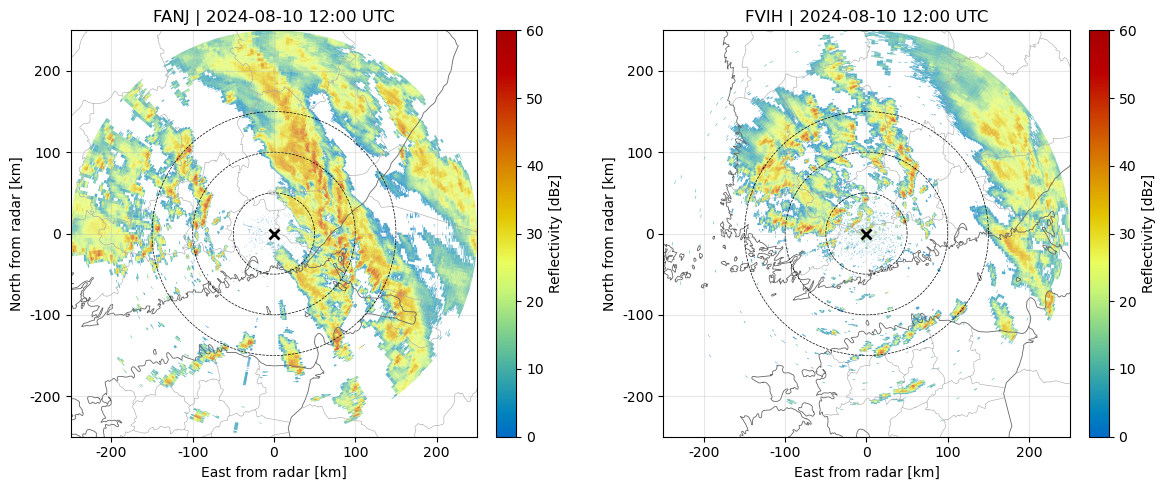

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

volumes = {}
for ax, name in zip(axes, SOURCES, strict=False):
    # A radar may already hold other volumes from tutorial 1, so name the one
    # this notebook just archived rather than letting plot_ppi guess.
    volumes[name] = db.open(radars=name)
    volumes[name].plot_ppi(
        sweep=0,
        variable="DBZH",
        ax=ax,
        coords="xy",
        context=True,
        timestep=TIMES[name],
    )
    ax.set_title(f"{name} | {pd.Timestamp(TIMES[name]):%Y-%m-%d %H:%M} UTC")

plt.tight_layout()
plt.show()

## 5. A cross-section, drawn by hand

`interactive_crop()` puts an [ipyleaflet](https://ipyleaflet.readthedocs.io/) map
in front of you. It dispatches on the shape you draw — rectangle, polygon and
marker run the three crops, and the **polyline** runs
`extract_cross_section`, which is the one used here.

Draw a line, then click **Apply crop** before running the next cell.

In [ ]:
fanj = volumes["FANJ"]
selector = fanj.interactive_crop()

The drawn section is on `selector.result` — an ordinary RadDB, carrying the extra
`d_center` / `z_center` / `cs_polygon` columns that describe the curtain. Nothing
drawn (or no live kernel) falls back to a fixed line through the same storm, so
the plot below always has a section to draw.

nothing drawn — using the fixed line ((27.1080600656569, 60.90387001633644), (28.708060065656902, 61.80387001633644)): 33,508 gates


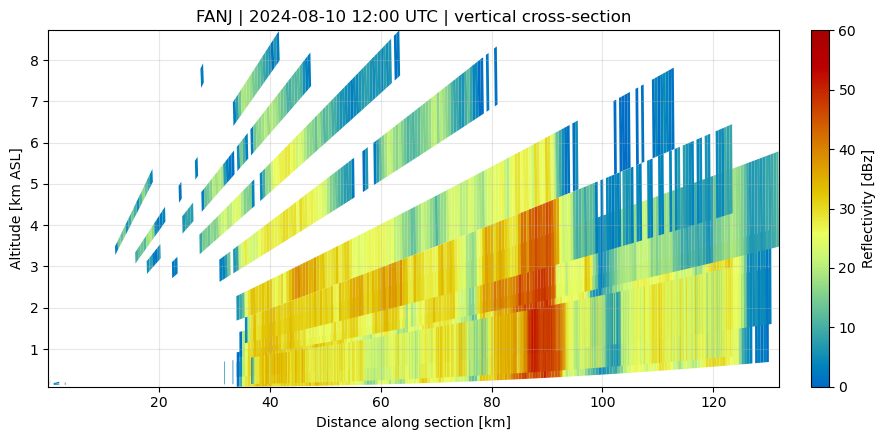

In [ ]:
# Fallback: a line from the radar out to the north-east, through the storm.
info = db.get_radar_info("FANJ")
SITE = (info["longitude"], info["latitude"])
LINE = (SITE, (SITE[0] + 1.6, SITE[1] + 0.9))

drawn = getattr(selector, "result", None)
if drawn is not None and selector.kind == "cross_section":
    section = drawn
    print(f"drawn section: {len(section):,} gates")
else:
    section = fanj.extract_cross_section(p1=LINE[0], p2=LINE[1], crs=4326)
    print(f"nothing drawn — using the fixed line {LINE}: {len(section):,} gates")

fig, ax = plt.subplots(figsize=(9, 4.5))
section.plot_vcs(variable="DBZH", timestep=TIMES["FANJ"], ax=ax)
ax.set_title(f"FANJ | {pd.Timestamp(TIMES['FANJ']):%Y-%m-%d %H:%M} UTC | vertical cross-section")
plt.tight_layout()
plt.show()

---

That is the whole pipeline: **download → archive → open → plot → cut**. The
archive now holds one more radar, and everything the other notebooks do —
filters, label selection, the other three crops, RHI, CAPPI — applies to it
unchanged.

**See also:** [1 — Archiving](01_archiving.ipynb) ·
[2 — Opening and filtering](02_opening_and_filtering.ipynb) ·
[3 — Areas of interest](03_area_of_interest.ipynb) ·
[4 — Plots](04_plots.ipynb)